# Terminal rendering with meshio++ (C++ / xeus-cpp)

C++ counterpart of [`../python/31_terminal_rendering.ipynb`](../python/31_terminal_rendering.ipynb): meshio++'s own **software rasterizer** (`operations/render.hpp`) draws a mesh with no display, GPU or plotting library, called directly in C++ (`render`, `encode_png`, `render_text`, `write_snapshot`). Unlike the SVG route of the other C++ notebooks, this one takes **every** option of the rasterizer, so the pictures below are coloured by data, with contour lines, arrows, streamlines and a cut-away. See [`doc/tui.md`](../../doc/tui.md) and [`doc/cpp_api.md`](../../doc/cpp_api.md).

`frame_image` in [`mio_notebook.hpp`](mio_notebook.hpp) encodes a frame as a PNG and wraps it so `xcpp::display` shows it inline.

In [1]:
#define MESHIOPLUSPLUS_IMPLEMENTATION
#include "../../src/single_include/meshioplusplus/meshioplusplus.hpp"
#include "mio_notebook.hpp"
#include <iostream>
#include <algorithm>
#include <cmath>

using namespace meshioplusplus;
using namespace mio_nb;

In [2]:
Mesh mesh = registry_read("example.vtu", resolve_format("example.vtu", ""), {});
std::cout << "points: " << mesh.NumPoints() << ", blocks:";
for (std::size_t b = 0; b < mesh.NumCellBlocks(); ++b) std::cout << " " << mesh.Cells(b).Type();
std::cout << "\n";

points: 52282, blocks: triangle tetra


## Some fields to draw

The bracket carries no solution, so make some from its geometry: a scalar `h`, a displacement `disp` and a rotation velocity `vel` about the part's vertical axis. A vector point array is `N x 3` doubles.

In [3]:
const std::size_t np = mesh.NumPoints();
const double* P = mesh.Points().As<double>();
double lo[3] = {1e300, 1e300, 1e300}, hi[3] = {-1e300, -1e300, -1e300}, mid[3] = {0, 0, 0};
for (std::size_t i = 0; i < np; ++i)
    for (int d = 0; d < 3; ++d) {
        lo[d] = std::min(lo[d], P[3 * i + d]);
        hi[d] = std::max(hi[d], P[3 * i + d]);
        mid[d] += P[3 * i + d] / double(np);
    }
NDArray h = NDArray::Uninit(DType::Float64, {np});
NDArray disp = NDArray::Uninit(DType::Float64, {np, std::size_t(3)});
NDArray vel = NDArray::Uninit(DType::Float64, {np, std::size_t(3)});
for (std::size_t i = 0; i < np; ++i) {
    h.As<double>()[i] = P[3 * i] + 0.5 * P[3 * i + 1];
    disp.As<double>()[3 * i] = 0.0;
    disp.As<double>()[3 * i + 1] = 0.0;
    disp.As<double>()[3 * i + 2] = 0.15 * (P[3 * i] - lo[0]) / (hi[0] - lo[0]);
    vel.As<double>()[3 * i] = -(P[3 * i + 1] - mid[1]);
    vel.As<double>()[3 * i + 1] = P[3 * i] - mid[0];
    vel.As<double>()[3 * i + 2] = 0.0;
}
mesh.AddPointData("h", std::move(h));
mesh.AddPointData("disp", std::move(disp));
mesh.AddPointData("vel", std::move(vel));
std::cout << "point data added: h, disp, vel\n";

point data added: h, disp, vel


## A frame

A `RenderOptions` carries the camera, shading, edges and colours; a volume is drawn through its boundary skin. `edges = Feature` draws the sharp edges (the `feature_edges` ones).

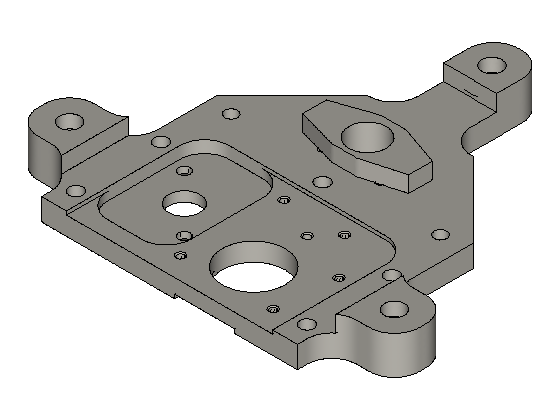

In [4]:
RenderOptions plain;
plain.mEdges = RenderEdges::Feature;
plain.mShading = RenderShading::Smooth;
plain.mBackground = {255, 255, 255, 255};
xcpp::display(frame_image(mesh, plain));

## Colouring by data

`mColorBy` takes point data first, then cell data. `render` returns a `Frame` with the pixels, the cell id of every pixel and the notes a terminal rendering prints under its picture.

range: -4.18187 .. -0.00318038
h: -4.18187 .. -0.00318038 (plasma)
ticks: -4, -3, -2, -1


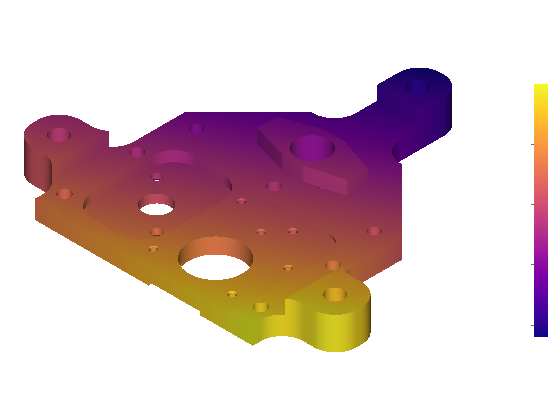

In [5]:
RenderOptions colored;
colored.mColorBy = "h";
colored.mCmap = "plasma";
colored.mColorbar = true;
colored.mShading = RenderShading::Smooth;
Frame f = render(mesh, colored);
std::cout << "range: " << f.mVMin << " .. " << f.mVMax << "\n";
for (const std::string& note : f.mNotes) std::cout << note << "\n";
xcpp::display(frame_image(mesh, colored));

## Field options

Contour lines of a point array, arrows for a vector array, and a warp by a displacement that also draws the undeformed outline.

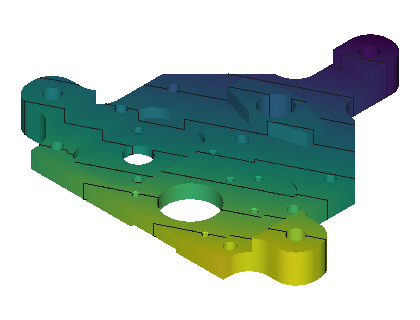

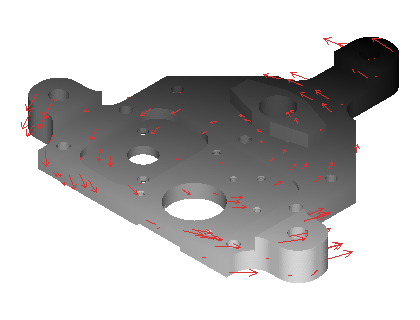

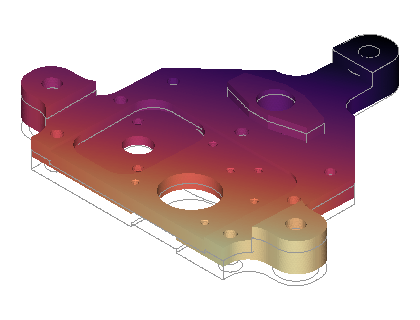

In [6]:
RenderOptions iso;
iso.mColorBy = "h"; iso.mIsolines = 8;
xcpp::display(frame_image(mesh, iso, 420, 320));
RenderOptions arrows;
arrows.mColorBy = "h"; arrows.mCmap = "grey"; arrows.mVectors = "vel"; arrows.mVectorCount = 300;
xcpp::display(frame_image(mesh, arrows, 420, 320));
RenderOptions warped;
warped.mColorBy = "h"; warped.mCmap = "magma"; warped.mWarp = "disp"; warped.mWarpOutline = true;
xcpp::display(frame_image(mesh, warped, 420, 320));

## Streamlines

Added in v16.37.0. `mStreamlines = "vel"` follows a vector point array over the mesh's own cells: on the skin (a surface) the lines stay on it, and in the volume they run inside it, so a cut-away shows them. A `RenderCutaway` is a point and the normal of the side kept; `-z` through the middle keeps the lower half and tints the inside.

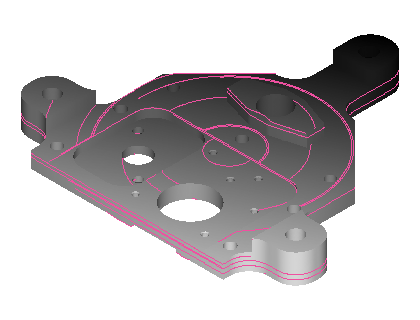

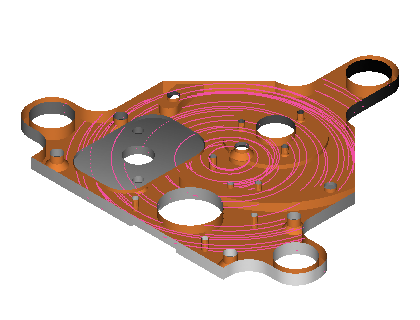

In [7]:
Mesh skin = extract_skin(mesh, /*linearize=*/true);
RenderOptions lines;
lines.mColorBy = "h"; lines.mCmap = "grey"; lines.mShading = RenderShading::Smooth;
lines.mStreamlines = "vel"; lines.mStreamSeeds = 60; lines.mStreamLength = 0.4;
xcpp::display(frame_image(skin, lines, 420, 320));

lines.mStreamSeeds = 120;
RenderCutaway cut;
cut.mPoint = {mid[0], mid[1], mid[2]};
cut.mNormal = {0.0, 0.0, -1.0};
lines.mCutaways = {cut};
xcpp::display(frame_image(mesh, lines, 420, 320));

## The terminal form

`render_text` returns what a terminal prints: block glyphs with colour escapes, or glyphs only with `TextFormat::Plain`.

In [8]:
TextOptions text;
text.mEncoding = TextEncoding::Braille;
text.mFormat = TextFormat::Plain;
text.mCols = 64;
text.mRows = 18;
RenderOptions edges;
edges.mEdges = RenderEdges::Feature;
std::cout << render_text(mesh, edges, text);

⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣤⣶⢟⣛⡻⣶⣤⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢶⣭⡛⠬⣭⣥⠿⡋⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣀⣀⣀⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣀⣤⣤⣤⣤⣤⣤⣤⣤⣤⡤⢀⠤⠤⣤⣀⣀⠀⠀⣀⣠⣴⣾⣷⣦⣉⠓⡎⣴⣮⡇⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⣶⣿⠫⣭⡍⢻⣷⡦⢄⠀⠀⠀⠀⢀⣠⣴⣿⣿⣅⣒⣽⣿⣿⣿⣿⣿⠑⢾⣿⣿⡿⠶⡪⠭⢙⠿⣿⣿⣿⣿⣿⣿⡿⢛⣠⣿⡿⠃⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⢈⡛⢷⣶⠾⣛⢥⡶⣛⣤⣤⡄⠬⠹⠟⣛⣛⣛⡻⢿⣿⣿⣿⣿⣿⣿⣄⠀⠙⠏⢰⣿⣿⣿⠇⣱⣎⠻⣿⣿⣿⡏⢸⠿⠛⠁⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⢸⣿⠀⣴⠎⣢⣵⣾⣿⣿⠿⢛⡭⢖⠫⢭⣭⣭⣭⡓⠮⣙⠻⣿⣿⣿⣿⣧⣄⠳⣦⣔⣒⠶⢾⣿⣿⡷⠘⣿⣿⣷⡄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠘⠻⠀⠶⠿⢿⣿⠿⣋⠥⢚⣭⣾⣷⣥⣴⣿⣿⣿⣿⣷⣮⣄⢠⡙⠻⢿⠫⠭⣻⣶⣭⣛⠛⠳⣶⢰⠾⣃⣿⣿⣿⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⣐⡺⠮⠍⣈⠀⣪⣵⣾⣿⣿⡏⠖⠒⠒⠎⣿⣿⣿⡿⢛⣥⣎⠉⣷⣦⣌⡛⠿⣿⣿⣿⣿⣿⣶⣶⣾⣿⣿⣿⣿⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠻⢿⣦⣛⠿⣧⣝⡻⢿⣿⣿⣷⣦⣤⣤⡶⠟⣫⣵⣾⣿⣿⣿⣿⣿⣿⣿⣿⣶⣄⡉⠻⢿⣿⣿⣿⣿⣿⠿⣿⣿⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠛⠿⣦⣍⡻⢶⣬⣛⣛⣃⣀⣤⣶⣿⠿⣛⣛⣛⠛⢛⠿⣿⣀⣼⣿⣧⣤⣿⣷⣦⣈⢻⣿⣿⣧⣭⣼⡿⠃⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠉⠻⢷⣬⣙⠿⣧⣤⣿⣿⠁⠿⠛⠛⠛⠉⠑⠒⠈⣿⣿⣿⣿⣿⣿⣿⠟⠋⢼⣿⣿⠟⣫⣵⣾⠇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠉⠛⠿⣮⣝⡻⢿⣦⣀⠀⠀⠀⠀⠀⣀⣴⣿⣿⣿⡄⠜⣉⣴⠦⣉⣥⡉⠶⡿⠛⠉⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠙⠲⢬⣛⠿⣿⣿⡟⠛⣿⣿⠿⢛⣡⡶⢟⣩⣴⡟⣫⣭⢻⣷⣆⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠉⠛⣦⣝⡻⠖⣉⣄⠤⢉⠿⠰⣶⣭⡛⠷⠶⠶⠾⢛⡁⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀

## Files

`write_snapshot` picks the form from the extension (`.png`, `.txt`, `.ansi`, `.html`, or a `.cast` orbit for asciinema).

In [9]:
TextOptions cells;
cells.mCols = 60;
cells.mRows = 16;
SnapshotOptions snap;
snap.mCastFrames = 6;
RenderOptions shot = lines;
shot.mWidth = 320;
shot.mHeight = 240;
shot.mStreamSeeds = 30;
shot.mCutaways.clear();
for (const char* name : {"part.png", "part.txt", "part.html", "part.cast"}) {
    const std::string path = next_temp_path(std::string("_") + name);
    write_snapshot(path, mesh, shot, cells, snap);
    std::cout << name << ": " << read_text_file(path).size() << " bytes\n";
}

part.png: 307528 bytes
part.txt: 1267 bytes
part.html: 19998 bytes
part.cast: 73745 bytes
